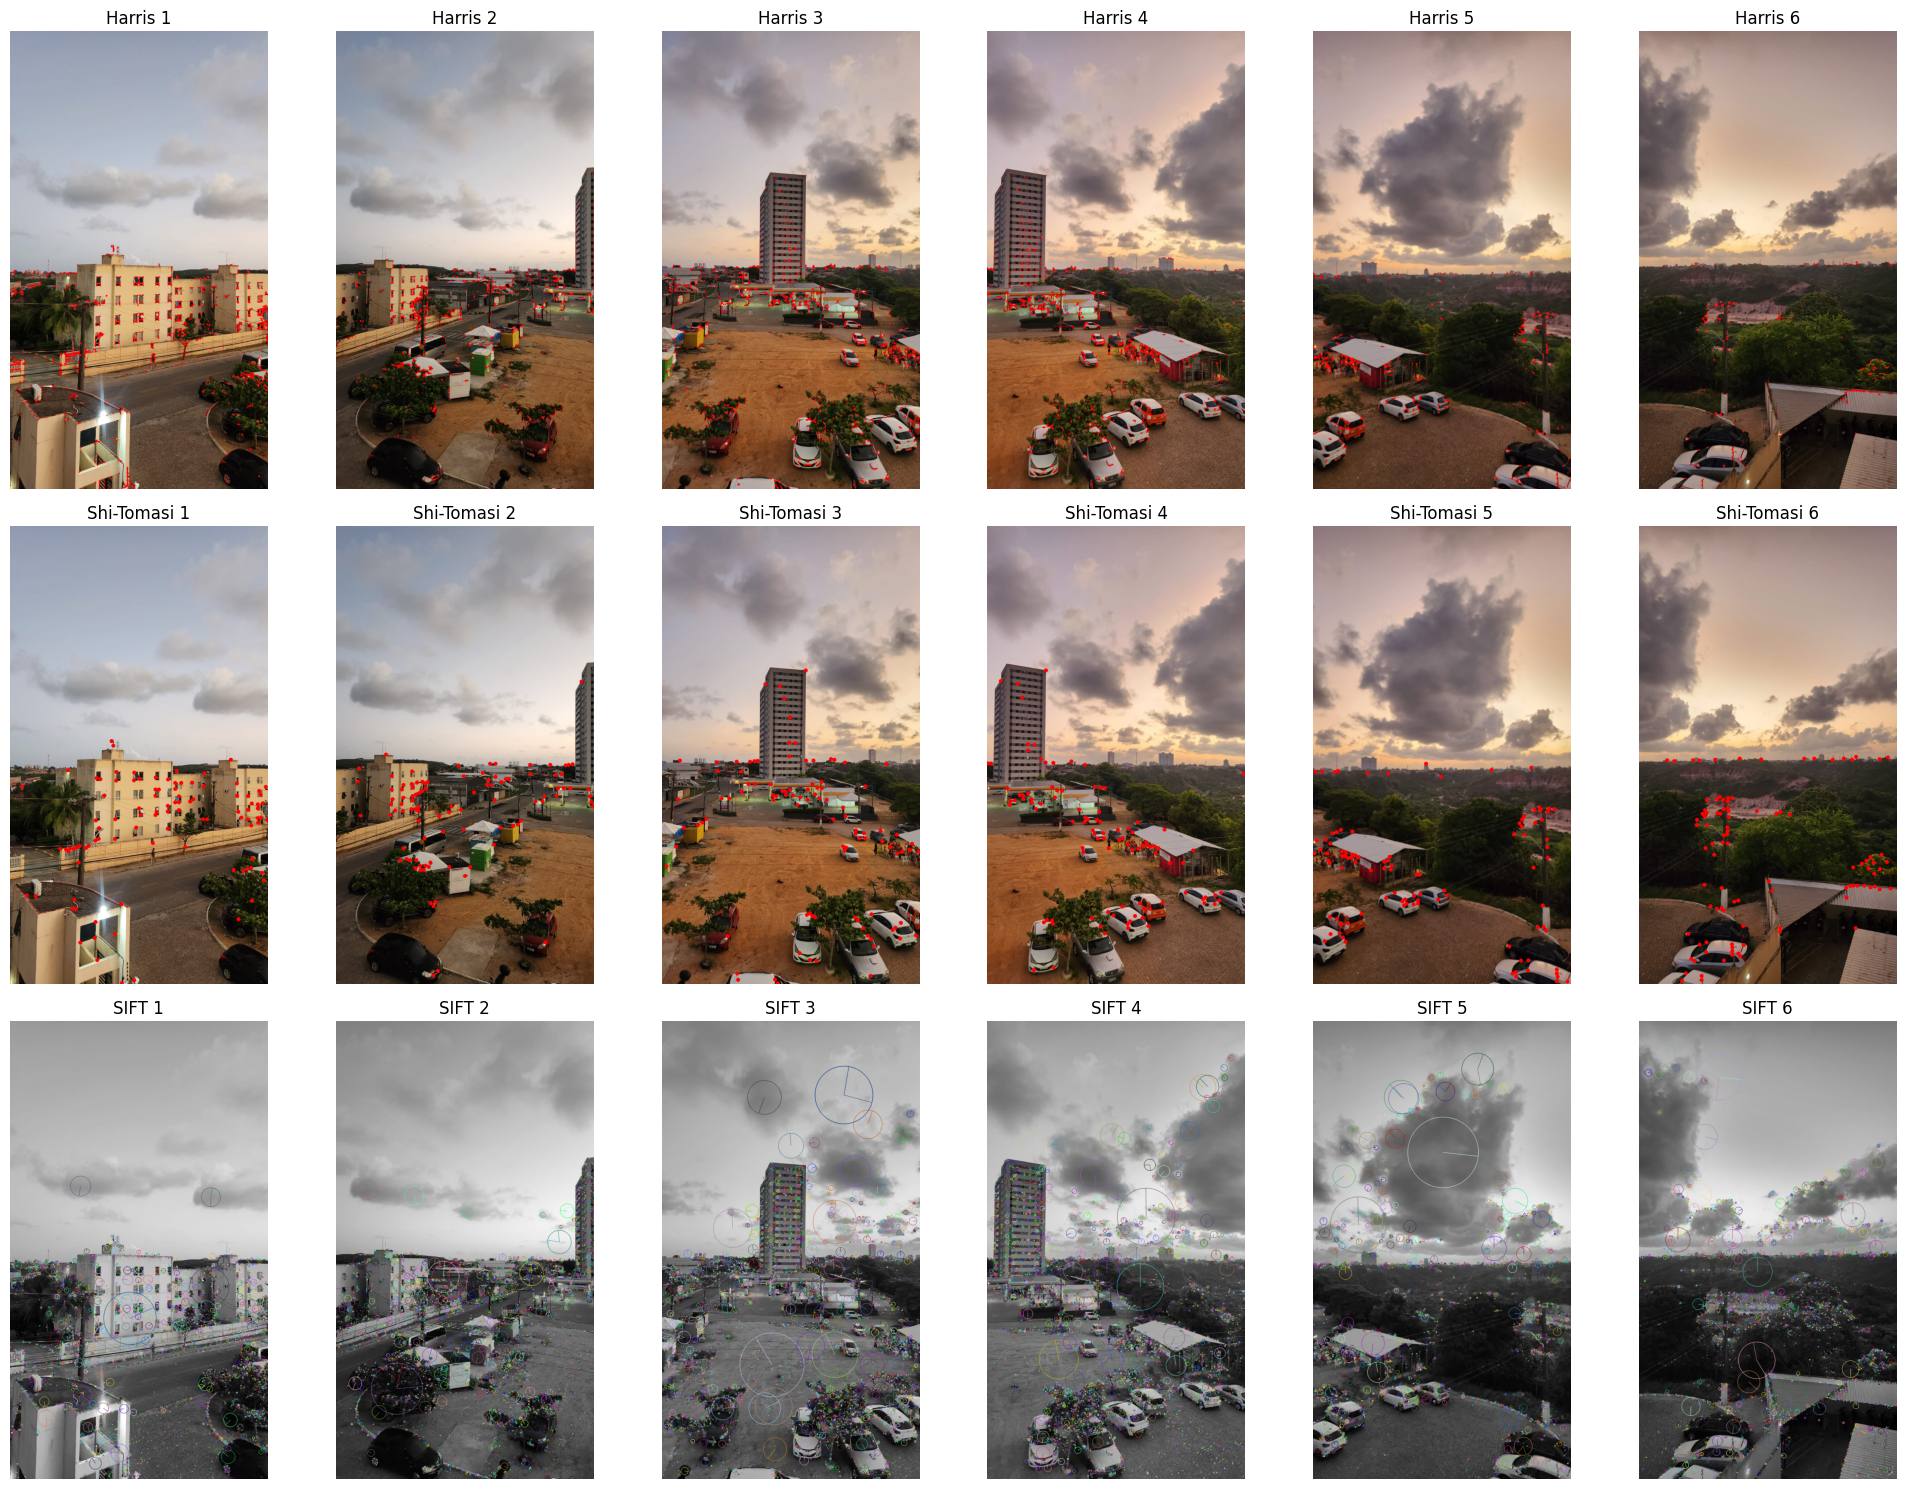

Harris execution time: 0.76 seconds
Shi-Tomasi execution time: 0.61 seconds
SIFT execution time: 5.31 seconds


In [13]:
import numpy as np
import cv2 as cv
import glob
import time
import os
import matplotlib.pyplot as plt

filename = sorted(glob.glob('img/task02/*.jpeg'))
fig, axes = plt.subplots(3, 6, figsize=(20, 15))

# Harris Corner Detector
start_time = time.time()
for idx, file in enumerate(filename):
    img = cv.imread(file)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    gray = np.float32(gray)

    blocksize = 2
    ksize = 7
    k = 0.04
    dst = cv.cornerHarris(gray, blocksize, ksize, k)
    dst = cv.dilate(dst, None)

    img[dst > 0.01 * dst.max()] = [0, 0, 255]

    axes[0, idx].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axes[0, idx].axis('off')
    axes[0, idx].set_title(f'Harris {idx+1}')
harris_time = time.time() - start_time

# Shi-Tomasi Corner Detector
start_time = time.time()
for idx, file in enumerate(filename):
    img = cv.imread(file)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    maxCorners = 100
    qualityLevel = 0.01
    minDistance = 10
    corners = cv.goodFeaturesToTrack(gray, maxCorners, qualityLevel, minDistance)
    corners = np.int_(corners)

    result = img.copy()

    for corner in corners:
        x, y = corner.ravel()
        cv.circle(result, (x, y), 7, [0, 0, 255], -1)

    axes[1, idx].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    axes[1, idx].axis('off')
    axes[1, idx].set_title(f'Shi-Tomasi {idx+1}')
shi_tomasi_time = time.time() - start_time

# SIFT Detector
start_time = time.time()
for idx, file in enumerate(filename):
    img = cv.imread(file)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    nfeatures = 0
    nOctaveLayers = 3
    contrastThreshold = 0.04
    edgeThreshold = 10
    sigma = 1.6
    sift = cv.SIFT_create(
        nfeatures=nfeatures,
        nOctaveLayers=nOctaveLayers,
        contrastThreshold=contrastThreshold,
        edgeThreshold=edgeThreshold,
        sigma=sigma
    )

    kp = sift.detect(gray, None)
    result = cv.drawKeypoints(gray, kp, img, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    axes[2, idx].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    axes[2, idx].axis('off')
    axes[2, idx].set_title(f'SIFT {idx+1}')
sift_time = time.time() - start_time

plt.tight_layout()
plt.show()

print(f"Harris execution time: {harris_time:.2f} seconds")
print(f"Shi-Tomasi execution time: {shi_tomasi_time:.2f} seconds")
print(f"SIFT execution time: {sift_time:.2f} seconds")

QUESTÃO I - Análise dos Detectores de Cantos/Features

CornerHarris<br>
O detector de Corner Harris analisa as variações em direção do gradiente pra encontrar quinas, ele gera bastante keypoints em áreas de cantos de objetos e bordas que tem bastante contraste. Principais parâmetros:
- blockSize: tamanho da vizinhança do pixel.
- ksize: tamanho do kernel na derivada Sobel.
- k: parâmetro de ajuste para sensibilidade.

Shi-Tomasi <br>
Também é um detector de cantos, mas usa um critério baseado em valores mínimos para selecionar os pontos mais estáveis. No teste, gerou menos features, porém melhor distribuídas e para o caso de teste, foram mais úteis para rastreamento espacial. Principais parâmetros:
- maxCorners: número máximo de cantos.
- qualityLevel: qualidade mínima aceitável.
- minDistance: distância mínima entre as detecções.

SIFT (Scale-Invariant Feature Transform) <br>
Detecta pontos analisando a imagem em múltiplas escalas (diferentes desfoques) via filtro Difference of Gaussians (DoG). Ele encontra features até em superfícies pouco definidas (como nuvens), capturando detalhes de textura e contraste sutil. Apresentou maior custo computacional dentre os 3. Principais parâmetros:
- nfeatures: limite de features.
- contrastThreshold: filtra cantos de baixo contraste.
- edgeThreshold: controla quão perto de bordas o detector vai atuar.
- sigma: suavização na pirâmide de escalas.

Qual foi o melhor? <br>
O Harris é bom para quinas bem definidas, mas sensível a ruídos em áreas homogêneas.
O Shi-Tomasi teve bom equilíbrio entre velocidade e distribuição de pontos, ajudando no rastreamento.
O SIFT é robusto a mudanças de escala, mas é o mais lento.
Para este cenário, escolhi o Shi-Tomasi como o melhor compromisso entre desempenho e distribuição de pontos.

In [ ]:
input = sorted(glob.glob('img/task02/*.jpeg'))
fig, axes = plt.subplots(3, 5, figsize=(20, 15))

# Função comum para todos os descritores
def detect_keypoints(gray):
    maxCorners = 500
    qualityLevel = 0.01
    minDistance = 10
    corners = cv.goodFeaturesToTrack(gray, maxCorners, qualityLevel, minDistance)
    keypoints = [cv.KeyPoint(x=float(x), y=float(y), size=7) for [[x, y]] in corners]
    return keypoints

# SIFT descriptor com Shi-Tomasi detector
start_time = time.time()
for idx in range(len(input)-1):
    img1, img2 = cv.imread(input[idx]), cv.imread(input[idx+1])
    gray1, gray2 = cv.cvtColor(img1, cv.COLOR_BGR2GRAY), cv.cvtColor(img2, cv.COLOR_BGR2GRAY)
    
    # Detector ST
    kp1 = detect_keypoints(gray1)
    kp2 = detect_keypoints(gray2)
    
    # Descriptor SIFT
    sift = cv.SIFT_create()
    kp1, des1 = sift.compute(gray1, kp1)
    kp2, des2 = sift.compute(gray2, kp2)
    
    # Matching com FLANN
    if des1 is not None and des2 is not None:
        flann = cv.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
        matches = flann.knnMatch(des1, des2, k=2)
        
        good_matches = []
        for m, n in matches:
            if m.distance < 0.7 * n.distance:
                good_matches.append(m)
                
        result = cv.drawMatches(img1, kp1, img2, kp2, good_matches, None)
    else:
        result = np.hstack((img1, img2))

    axes[0, idx].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    axes[0, idx].set_title(f'SIFT desc. {idx+1}-{idx+2}')
    axes[0, idx].axis('off')

sift_time = time.time() - start_time

# ORB descriptor com Shi-Tomasi detector
start_time = time.time()
for idx in range(len(input)-1):
    img1, img2 = cv.imread(input[idx]), cv.imread(input[idx+1])
    gray1, gray2 = cv.cvtColor(img1, cv.COLOR_BGR2GRAY), cv.cvtColor(img2, cv.COLOR_BGR2GRAY)
    
    # Detector ST
    kp1 = detect_keypoints(gray1)
    kp2 = detect_keypoints(gray2)
    
    # Descriptor ORB
    orb = cv.ORB_create()
    kp1, des1 = orb.compute(gray1, kp1)
    kp2, des2 = orb.compute(gray2, kp2)
    
    # Matching com BruteForce
    if des1 is not None and des2 is not None:
        bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
        matches = bf.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)[:10]
        
        result = cv.drawMatches(img1, kp1, img2, kp2, matches, None,
                              matchColor=(0, 255, 0),
                              singlePointColor=(255, 0, 0),
                              flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
                              thickness=2)
    else:
        result = np.hstack((img1, img2))
    
    axes[1, idx].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    axes[1, idx].set_title(f'ORB desc. {idx+1}-{idx+2}')
    axes[1, idx].axis('off')

orb_time = time.time() - start_time

# BRISK descriptor com Shi-Tomasi detector
start_time = time.time()
for idx in range(len(input)-1):
    img1, img2 = cv.imread(input[idx]), cv.imread(input[idx+1])
    gray1, gray2 = cv.cvtColor(img1, cv.COLOR_BGR2GRAY), cv.cvtColor(img2, cv.COLOR_BGR2GRAY)
    
    # Detector ST
    kp1 = detect_keypoints(gray1)
    kp2 = detect_keypoints(gray2)
    
    # Descriptor BRISK
    brisk = cv.BRISK_create()
    kp1, des1 = brisk.compute(gray1, kp1)
    kp2, des2 = brisk.compute(gray2, kp2)
    
    # Matching com BruteForce
    if des1 is not None and des2 is not None:
        bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
        matches = bf.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)[:50]
        
        result = cv.drawMatches(img1, kp1, img2, kp2, matches, None,
                              matchColor=(0, 255, 0),
                              singlePointColor=(255, 0, 0),
                              flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
                              thickness=2)
    else:
        result = np.hstack((img1, img2))
    
    axes[2, idx].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    axes[2, idx].set_title(f'BRISK desc. {idx+1}-{idx+2}')
    axes[2, idx].axis('off')

brisk_time = time.time() - start_time

print(f"SIFT descriptor time: {sift_time:.2f} s")
print(f"ORB descriptor time: {orb_time:.2f} s")
print(f"BRISK descriptor time: {brisk_time:.2f} s")

plt.tight_layout()
plt.show()

Utilizei o método Shi-Tomasi como detector para encontrar os pontos de interesse (features/keypoints) em todas as imagens. Posterior, aproveito esses mesmos pontos localizados e aplico cada um dos seguintes descritores (escolhidos por mim, exceto pelo SIFT que foi pedido no enunciado da questão):

- SIFT: Baseia-se em gradientes para gerar descritores em float (em 128 dimensões). Normalmente por ser em foat é mais preciso e também "resistente" a mudanças de escala. No matching, usei o FLANN para lidar com essas dimensões.

- ORB: Embora dê para utilizar ORB combinado com FAST (detector) e também com o BRIEF (descritor), aqui aproveitei apenas a função do descritor. Ele gera vetores binários, são bem mais leves e rápidos para comparar, ao contrário dos floats (SIFT).

- BRISK: Também binário, mas funciona a partir de um padrão circular que aparentemente capta informações de vizinhança. Não foi tão rápido quanto o ORB, mas tem boa solidez. Aqui, usamos o BFMatcher porque ele lida bem com dados binários.

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import glob

def find_multiple_labels(labels_dir, product_image_path, confidence_threshold=0.1, max_results=5):
    start_time = time.time()
    
    # Carregar a imagem do produto e definir tamanho máximo
    product_img = cv.imread(product_image_path)
    max_dimension = 600

    # Preprocess das labels
    gray_product = cv.cvtColor(product_img, cv.COLOR_BGR2GRAY)
    gray_product = cv.GaussianBlur(gray_product, (3, 3), 0)
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_eq = clahe.apply(gray_product)
    sharpening_kernel = np.array([[0, -1, 0],
                                  [-1, 5, -1],
                                  [0, -1, 0]])
    gray_sharp = cv.filter2D(gray_eq, -1, sharpening_kernel)
    
    # SIFT - Detectando e descrevendo as features, keypoints.
    sift = cv.SIFT_create()
    product_keypoints, product_descriptors = sift.detectAndCompute(gray_sharp, None)
    
    # Procurando as input labels (excluindo /find/)
    label_files = []
    if isinstance(labels_dir, str) and os.path.isdir(labels_dir):
        label_files = (glob.glob(os.path.join(labels_dir, '*.jpg')) +
                       glob.glob(os.path.join(labels_dir, '*.jpeg')) +
                       glob.glob(os.path.join(labels_dir, '*.png')))
    elif isinstance(labels_dir, list):
        label_files = labels_dir
    label_files = [f for f in label_files if '/find/' not in f]
    
    detected_labels = []
    for label_file in label_files:
        label_name = os.path.splitext(os.path.basename(label_file))[0]
        label_img = cv.imread(label_file)
        if label_img is None:
            continue
        
        # Resize
        if max(label_img.shape[:2]) > max_dimension:
            scale = max_dimension / max(label_img.shape[:2])
            label_img = cv.resize(label_img, None, fx=scale, fy=scale)
        
        gray_label = cv.cvtColor(label_img, cv.COLOR_BGR2GRAY)
        gray_label = cv.GaussianBlur(gray_label, (3, 3), 0)
        gray_label_eq = clahe.apply(gray_label)
        gray_label_sharp = cv.filter2D(gray_label_eq, -1, sharpening_kernel)
        
        # SIFT no rótulo
        label_keypoints, label_descriptors = sift.detectAndCompute(gray_label_sharp, None)
        if not label_keypoints or len(label_keypoints) < 4:
            continue
        
        # Matching
        matcher = cv.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=150))
        matches = matcher.knnMatch(label_descriptors, product_descriptors, k=2)
        good_matches = [m for m, n in matches if m.distance < 0.85 * n.distance]
        if len(good_matches) < 4:
            continue
        
        src_pts = np.float32([label_keypoints[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([product_keypoints[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        H, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 10.0)
        if H is None or mask is None:
            continue
        
        inliers = [good_matches[i] for i in range(len(good_matches)) if mask[i] == 1]
        if len(inliers) < 4:
            continue
        
        # Homographie
        det = H[0,0] * H[1,1] - H[0,1] * H[1,0]
        if det <= 0.00001:
            continue
        
        scale_x = np.sqrt(H[0,0]**2 + H[1,0]**2)
        scale_y = np.sqrt(H[0,1]**2 + H[1,1]**2)
        ratio = scale_x / scale_y
        if not (0.2 < ratio < 5):
            continue
        
        confidence = len(inliers) / min(len(label_keypoints), 100)
        if confidence < confidence_threshold:
            continue
        
        h_label, w_label = label_img.shape[:2]
        corners = np.float32([[0, 0], [0, h_label-1],
                              [w_label-1, h_label-1], [w_label-1, 0]]).reshape(-1, 1, 2)
        transformed_corners = cv.perspectiveTransform(corners, H)
        rect = cv.minAreaRect(np.int32(transformed_corners))
        
        detected_labels.append({
            'name': label_name,
            'confidence': confidence,
            'homography': H,
            'corners': transformed_corners,
            'center': rect[0],
            'area': rect[1][0] * rect[1][1],
            'image': label_img
        })
    
    # Ordenar e limitar
    detected_labels.sort(key=lambda x: x['confidence'], reverse=True)
    detected_labels = detected_labels[:max_results]
    
    # Cores para diferenciar os rotulos
    colors = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),
              (255,0,255),(0,255,255),(128,0,255),(255,128,0)]
    
    # Clonar para draw bounding boxes
    annotated_img = product_img.copy()
    for i, det in enumerate(detected_labels):
        color = colors[i % len(colors)]
        poly = np.int32(det['corners'])
        cv.polylines(annotated_img, [poly], True, color, 5)
        cx, cy = map(int, det['center'])
        cv.putText(
            annotated_img,
            f"{det['name']} ({det['confidence']:.2f})",
            (cx, cy),
            cv.FONT_HERSHEY_SIMPLEX, 0.8, color, 2
        )
    
    # Plot da imagem principal + rótulos ao lado
    fig = plt.figure(figsize=(14, 8))
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.set_title(f"Rótulos Detectados ({len(detected_labels)}) - {os.path.basename(product_image_path)}")
    ax1.imshow(cv.cvtColor(annotated_img, cv.COLOR_BGR2RGB))
    ax1.axis('off')
    
    # Subplot 2: miniaturas dos rótulos
    combined_height = sum(img['image'].shape[0] for img in detected_labels)
    max_width = max(img['image'].shape[1] for img in detected_labels)
    labels_canvas = np.zeros((combined_height, max_width, 3), dtype=np.uint8)
    
    y_offset = 0
    for i, det in enumerate(detected_labels):
        label_img = det['image']
        h_l, w_l = label_img.shape[:2]
        colorscale = colors[i % len(colors)]
        
        labels_canvas[y_offset:y_offset+h_l, 0:w_l] = label_img
        
        # Draw bounding
        cv.rectangle(labels_canvas, (0, y_offset), (w_l-1, y_offset+h_l-1), colorscale, 5)
        
        y_offset += h_l
    
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(cv.cvtColor(labels_canvas, cv.COLOR_BGR2RGB))
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Tempo total: {time.time() - start_time:.2f} s\n")
    return detected_labels

def process_find_images(labels_dir, find_folder, confidence_threshold, max_results):
    label_files = (glob.glob(os.path.join(labels_dir, '*.jpg')) +
                  glob.glob(os.path.join(labels_dir, '*.jpeg')) +
                  glob.glob(os.path.join(labels_dir, '*.png')))
    label_files = [f for f in label_files if '/find/' not in f]
    print(f"{len(label_files)} rótulos")

    find_files = glob.glob(os.path.join(find_folder, '*.jpg')) + \
                 glob.glob(os.path.join(find_folder, '*.jpeg')) + \
                 glob.glob(os.path.join(find_folder, '*.png'))
    print(f"{len(find_files)} imagens")
    
    all_results = {}
    for img_path in find_files:
        results = find_multiple_labels(labels_dir, img_path, confidence_threshold, max_results)
        if results:
            all_results[img_path] = results
    
    return all_results

if __name__ == "__main__":
    labels_directory = '/Users/luryand/Documents/VC/img/task02/rotulos/'
    find_folder = '/Users/luryand/Documents/VC/img/task02/rotulos/find'

    all_detected = process_find_images(labels_directory, find_folder, confidence_threshold=0.5, max_results=3)
    
    print("\nResumo final:")
    for img_path, results in all_detected.items():
        desc = [(x['name'], f"{x['confidence']:.2f}") for x in results]
        print(f"Imagem {os.path.basename(img_path)} => {desc}")

3 rótulos
1 imagens
Erro ao carregar imagem da URL https://raw.githubusercontent.com/Delevati/vc-2024-2/ae2e5a018f90078817f439cbd9fe46628482f61f/img/task02/rotulos/find/20250323_175455.jpg: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>
Não foi possível carregar a imagem do produto

Resumo final:


    (a) Construção da base de pelo menos 10 rótulos:
Organizei um conjunto de pelo menos 8 imagens de rótulos, cada uma representando um item diferente. Armazenei todas em uma pasta (por exemplo, /rotulos/) e certifiquei que cada imagem tenha dimensionamento razoável (no máximo 600 px em um dos lados).

    (b) Metodologia de matching e parametrizações:
Primeiramente, a imagem do produto é carregada e passa pelo mesmo fluxo de pré-processamento que os rótulos:
    - Conversão para tons de cinza.
    - Aplicação de filtragem (blur) para suavizar ruídos.
    - Equalização local (CLAHE) para melhorar o contraste.
    - Sharpening para realçar bordas.
    - Extraio keypoints e descritores com SIFT no produto e em cada rótulo.
    - Emprego o FLANN para comparar descritores e, se houver matchs suficientes, calculo a homografia -usando RANSAC.
    - Verifico a qualidade da homografia com métricas como det e ratio de escalas, descartando as que estiverem fora do intervalo plausível.
    - Cada rótulo detectado recebe uma confiança baseada no número de pontos correspondentes em relação às features disponíveis.
    - Ordeno os rótulos por confiança, desenho contornos na imagem do produto e gero um mosaico de miniaturas dos rótulos encontrados.

    (c) Testar com 4 imagens diferentes do produto:
Para avaliar , testei com 4 fotos de produtos que estavam na base de rótulos, variando ângulos e iluminação. Registrei quantos rótulos foram corretamente identificados, como correspondências falsamente positivas em bordas irrelevantes dos rótulos ou falhas de detecção por pouca iluminação e qualidade dos inputs.

In [ ]:
input_images = sorted(glob.glob('img/task02/LoG/log.jpeg'))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

def log_multiscale_detection(img_gray, sigmas):
    volume = []
    
    for sigma in sigmas:
        blurred = cv.GaussianBlur(img_gray, (0, 0), sigma)
        lap = cv.Laplacian(blurred, cv.CV_32F, ksize=3)
        volume.append(lap)
    
    return np.stack(volume, axis=0)

start_time = time.time()
img = cv.imread(input_images[0])
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

sigmas = [3, 6, 9, 12, 15, 18]
volume = log_multiscale_detection(img_gray, sigmas)
marked = cv.cvtColor(img_gray, cv.COLOR_GRAY2BGR)

maxima_count = 0
for s in range(1, len(sigmas)-1):  # Ignora primeira e última escala
    for y in range(1, img_gray.shape[0]-1):  # Ignora bordas
        for x in range(1, img_gray.shape[1]-1):  # Ignora bordas
            val = volume[s, y, x]
            region_3d = volume[s-1:s+2, y-1:y+2, x-1:x+2]
            if val == region_3d.max() and val > 0:
                marked[y, x] = (0, 0, 255)
                maxima_count += 1

for i, sigma in enumerate(sigmas):
    row, col = i // 3, i % 3
    axes[row, col].imshow(volume[i], cmap='gray')
    axes[row, col].set_title(f'LoG (sigma={sigma})')
    axes[row, col].axis('off')

processing_time = time.time() - start_time

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(cv.cvtColor(marked, cv.COLOR_BGR2RGB))
plt.title(f"Máximos Locais (total: {maxima_count})")
plt.axis('off')
plt.show()

print(f"LoG processing time: {processing_time:.2f} s")

O LoG (Laplacian of Gaussian) primeiro aplica a Gaussiana pra suavizar a imagem, reduzindo ruído. Em seguida, entra o Laplaciano (derivada de segunda ordem) que realça as bordas. A gente faz isso em várias escalas (mudando o sigma da Gaussiana), então cada escala mostra contornos de tamanhos diferentes. Com sigma baixo (tipo 1), a suavização é menor e pode deixar ruído; com sigma alto (tipo 5 ou 6), a imagem fica mais borrada, perdendo detalhes finos.

Pra checar se um ponto é máximo local, comparo o valor dele com seus vizinhos no espaço 3D (posição + escala). Se for maior que todos ao redor (cubo 3×3×3), marco como máximo. Assim, o LoG detecta pontos de interesse em diferentes tamanhos na imagem.

Verificar o máximo local no espaço 3D (incluindo escala) é importante porque mostra que uma característica é realmente significativa não só em relação a seus vizinhos na mesma escala, mas também em escalas próximas. Isso nos dá um detector invariante à escala, ou seja, pode encontrar a mesma característica mesmo se a imagem for ampliada ou reduzida. Como pede a questão, ignoramos os pixels de borda e as escalas extremas, já que eles não têm vizinhança completa para comparação.